In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

!pip install bertopic
from bertopic import BERTopic

!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans

!pip install hdbscan
import hdbscan

from sklearn.preprocessing import normalize
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.7 MB/s eta 0:00:00


In [3]:
file_path = "/content/corpus_lecturebank.tsv"

df = pd.read_csv(file_path, sep="\t", header=None)
df.columns = ["text", "split", "label"]

df = df.drop(columns=["split"])

# Preview
df.head()

,text,label
0,Learning From Data Lecture 13 Validation and M...,"Neural Architectures, Training Neural Networks"
1,Lecture 11: Annotation Nathan Schneider (with ...,Introduction
2,Linear Classifiers and Perceptron CS6780 – Adv...,Machine Learning
3,NLP Introduction to NLP Parts of speech Syntac...,Parts of Speech
4,2/23/2019 pooling slides Maximum Pooling and A...,Introduction to Neural Networks and Deep Learning


In [4]:
texts = df["text"].astype(str).tolist()
texts

['Learning From Data Lecture 13 Validation and Model Selection The Validation Set Model Selection Cross Validation M. Magdon-Ismail CSCI 4100/6100 recap: Regularization Regularization combats the eﬀects of noise by putting a leash on the algorithm. Eaug(h) = Ein(h) + λ N Ω(h) Ω(h) → smooth, simple h noise is rough, complex. Diﬀerent regularizers give diﬀerent results can choose λ, the amount of regularization. λ = 0 λ = 0.0001 λ = 0.01 λ = 1 Data Target Fit y y y y x Overﬁtting x → x → x Underﬁtting Optimal λ balances approximation and generalization, bias and variance. AML Creator: Malik Magdon-Ismail c (cid:13) Validation and Model Selection: 2 /31 Peeking at Eout −→ Validation: A Sneak Peek at Eout Eout(g) = Ein(g) + overﬁt penalty VC bounds this using a complexity error bar Ω( ) H regularization estimates this through a heuristic complexity penalty Ω(g) {z | } Validation goes directly for the jugular: Eout(g) = Ein(g) + overﬁt penalty. validation estimates this directly | {z } In-s

In [58]:
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=42)

# Strip stopwords from topic keyword extraction
vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))

topic_model = BERTopic(
    verbose=True,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
)

topics, probs = topic_model.fit_transform(texts)
print(topics[:10])

2026-05-11 12:58:40,326 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

2026-05-11 12:59:07,445 - BERTopic - Embedding - Completed ✓
2026-05-11 12:59:07,446 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-11 12:59:07,777 - BERTopic - Dimensionality - Completed ✓
2026-05-11 12:59:07,778 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-11 12:59:07,791 - BERTopic - Cluster - Completed ✓
2026-05-11 12:59:07,796 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-11 12:59:08,374 - BERTopic - Representation - Completed ✓


[2, 0, 2, 0, 1, 3, 0, 2, 0, 2]


In [59]:
topic_model.get_topic_info().head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,28,-1_home_start_check_end,"[home, start, check, end, cross, learning, end...",[“Why Should I Trust You?” Explaining the Pred...
1,0,67,0_language_000_words_word,"[language, 000, words, word, np, model, retrie...",[Relation Extraction Bill MacCartney CS224U 18...
2,1,23,1_learning_deep_deep learning_course,"[learning, deep, deep learning, course, learni...",[Lecture 5: Modern ConvNets Efstratios Gavves ...
3,2,21,2_cid73_hypothesis_error_validation,"[cid73, hypothesis, error, validation, learnin...",[Learning From Data Lecture 13 Validation and ...
4,3,16,3_search_policy_chapter_state,"[search, policy, chapter, state, problem, opti...",[Introduction to Reinforcement Learning CS 294...


In [60]:
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(tid)[:8]]
    print(f"Topic {tid}: {', '.join(words)}")

Topic 0: language, 000, words, word, np, model, retrieval, natural
Topic 1: learning, deep, deep learning, course, learning course, neural, networks, gradient
Topic 2: cid73, hypothesis, error, validation, learning, training, data, set
Topic 3: search, policy, chapter, state, problem, optimal, cost, integer


In [61]:
len(set(topics))

5

In [62]:
sum(np.array(topics) == -1)

np.int64(28)

In [63]:
df["topic"] = topics
df

,text,split,label,topic
0,Learning From Data Lecture 13 Validation and M...,all,"Neural Architectures, Training Neural Networks",2
1,Lecture 11: Annotation Nathan Schneider (with ...,all,Introduction,0
2,Linear Classifiers and Perceptron CS6780 – Adv...,all,Machine Learning,2
3,NLP Introduction to NLP Parts of speech Syntac...,all,Parts of Speech,0
4,2/23/2019 pooling slides Maximum Pooling and A...,all,Introduction to Neural Networks and Deep Learning,1
...,...,...,...,...
150,Relation Extraction What is relation extractio...,all,Introduction,0
151,CS 6316 Machine Learning Model Selection and V...,all,Machine Learning,2
152,Automatic Dialect/Accent Recognition Fadi Biad...,all,Parts of Speech,0
153,10-707: Advanced Deep Learning Spring 2020 Lec...,all,Introduction to Neural Networks and Deep Learning,-1


In [64]:
topic_to_label = {}

for topic_id in set(topics):
    if topic_id == -1:
        continue

    majority_label = (
        df[df["topic"] == topic_id]["label"]
        .mode()[0]
    )

    topic_to_label[topic_id] = majority_label

print(topic_to_label)

{0: 'Introduction', 1: 'Introduction to Neural Networks and Deep Learning', 2: 'Machine Learning', 3: 'Introduction to AI'}


In [65]:
# Each document's predicted label comes from its topic's majority class
df["predicted_label"] = df["topic"].map(topic_to_label)

In [66]:
# Outliers have no predicted label; drop them before evaluation
df_eval = df[df["topic"] != -1].copy()
print(f"Evaluating on {len(df_eval)}/{len(df)} docs ({len(df) - len(df_eval)} outliers excluded)")

Evaluating on 127/155 docs (28 outliers excluded)


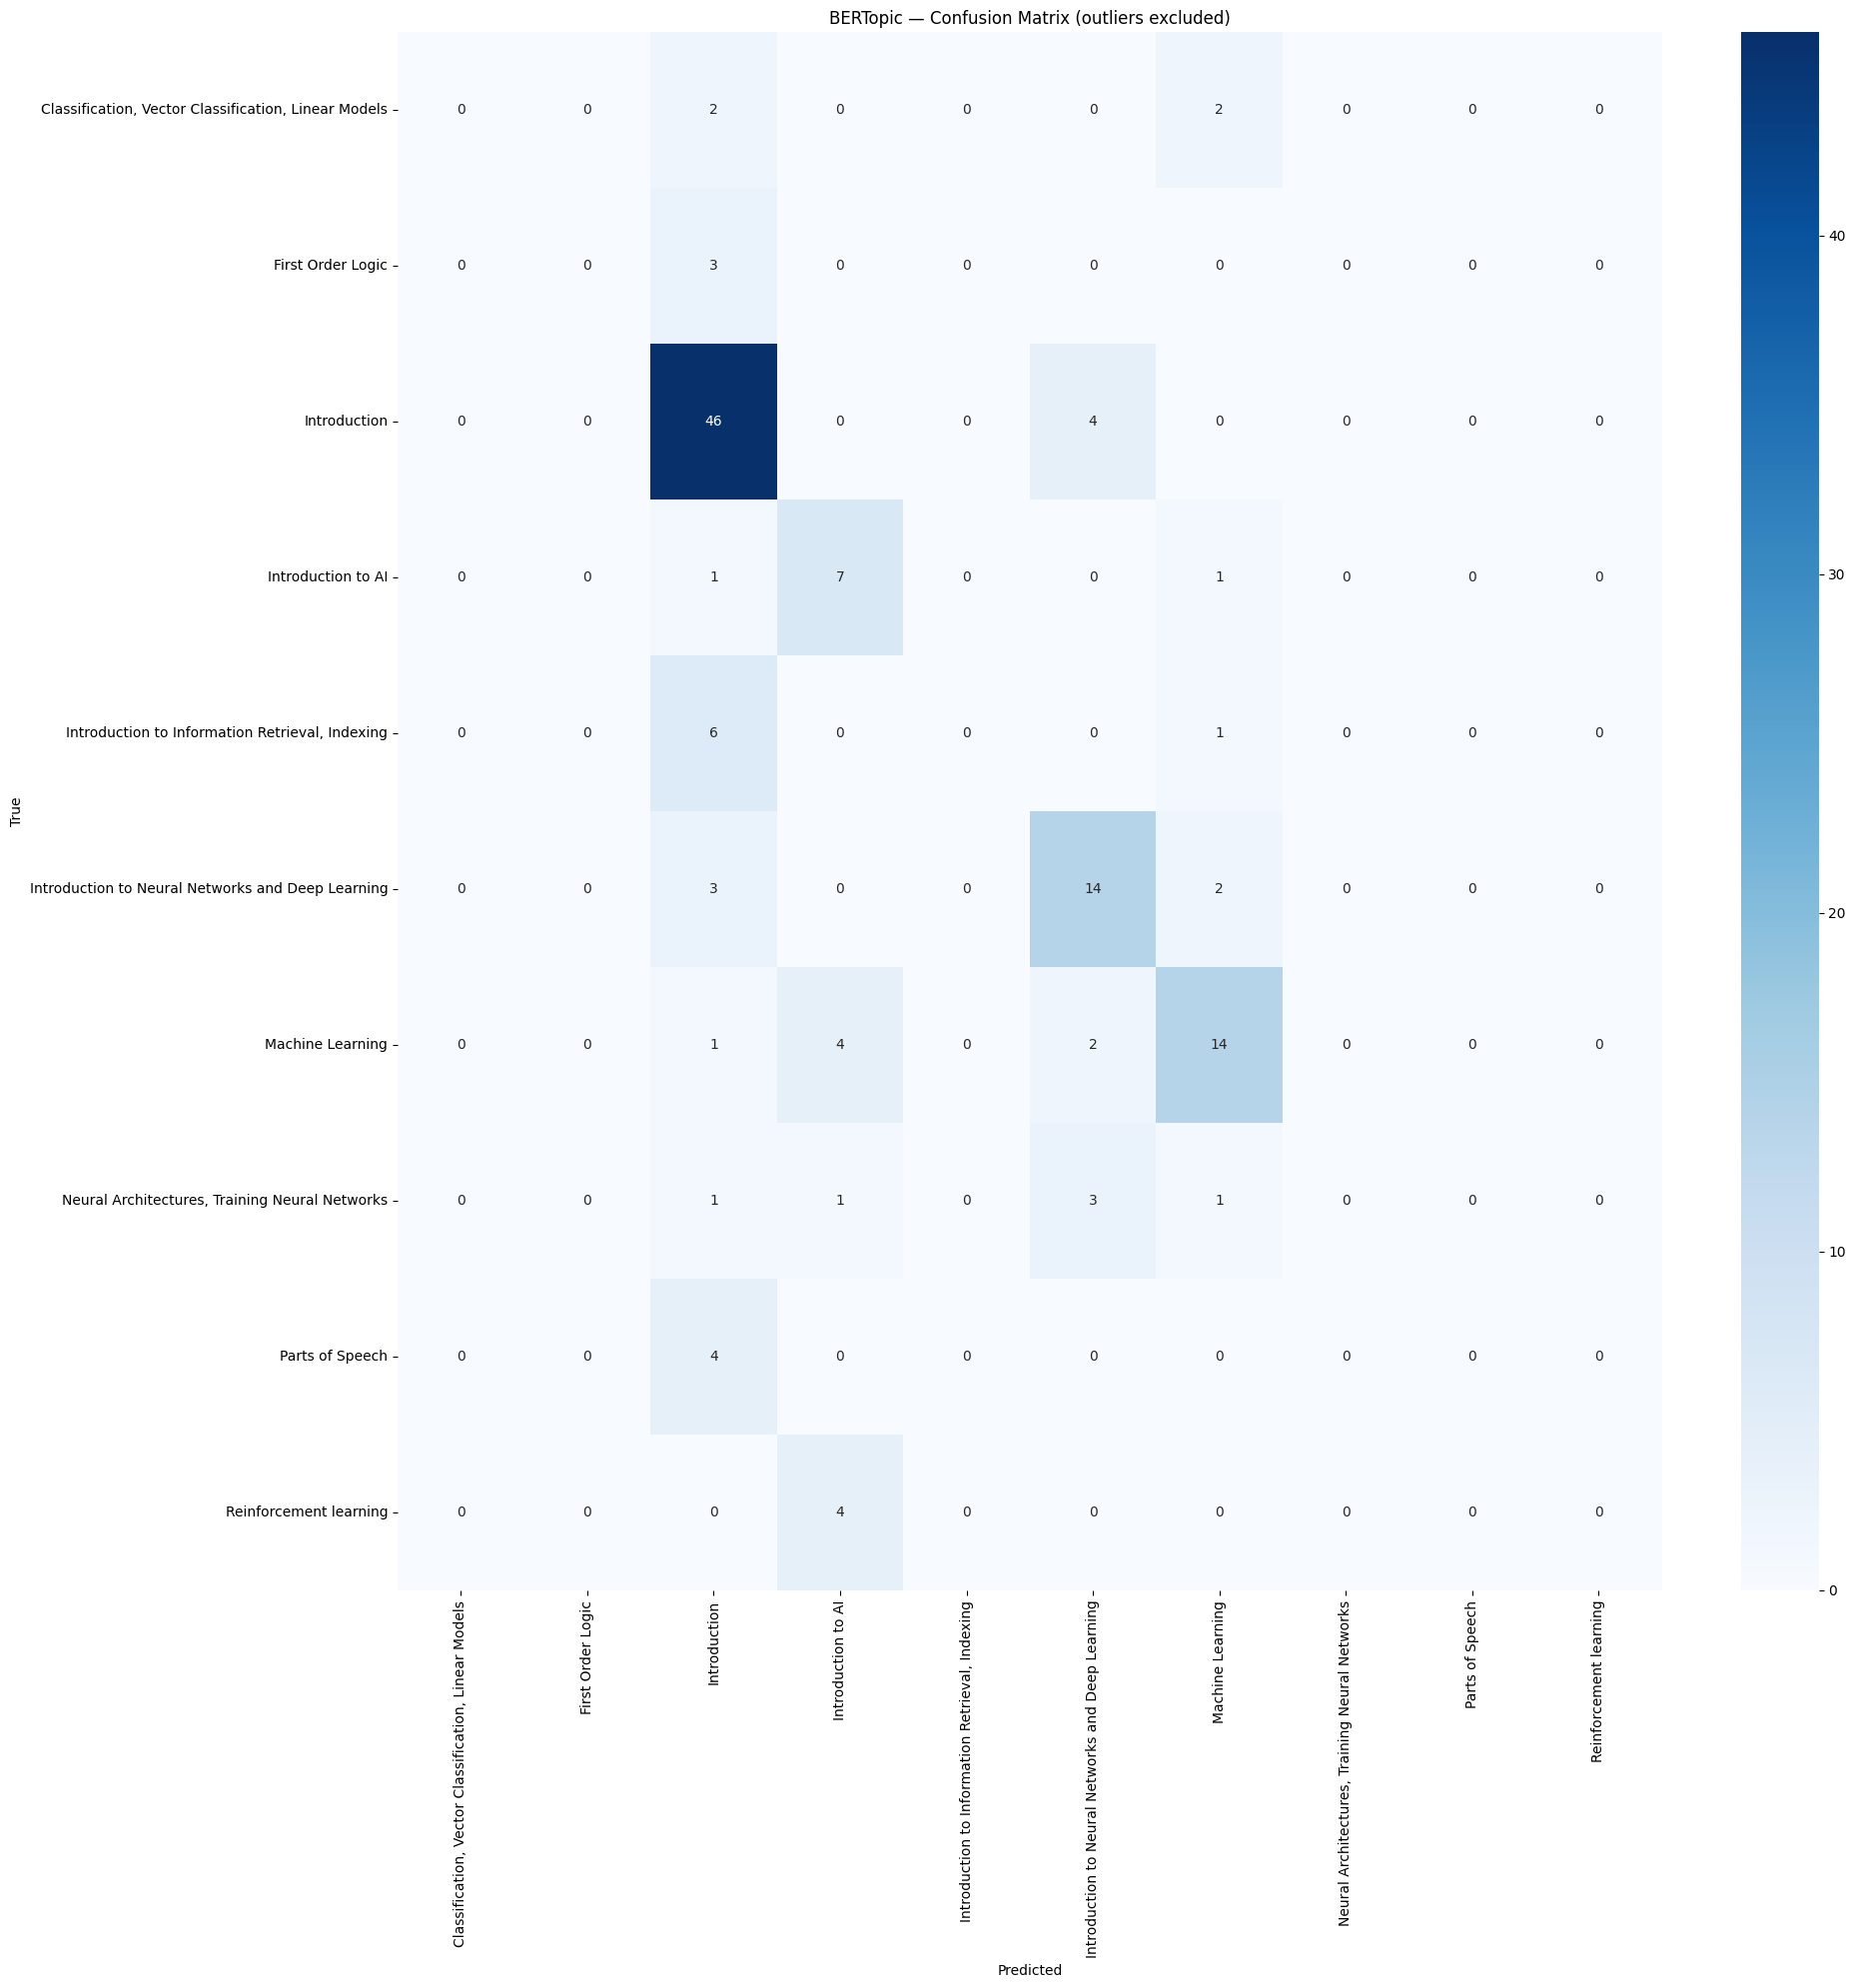

In [67]:
labels = sorted(df["label"].unique())

cm = confusion_matrix(df_eval["label"], df_eval["predicted_label"], labels=labels)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Confusion Matrix (outliers excluded)")
plt.tight_layout()
plt.show()

In [68]:
print(classification_report(df_eval["label"], df_eval["predicted_label"], labels=labels))

                                                      precision    recall  f1-score   support

Classification, Vector Classification, Linear Models       0.00      0.00      0.00         4
                                   First Order Logic       0.00      0.00      0.00         3
                                        Introduction       0.69      0.92      0.79        50
                                  Introduction to AI       0.44      0.78      0.56         9
     Introduction to Information Retrieval, Indexing       0.00      0.00      0.00         7
   Introduction to Neural Networks and Deep Learning       0.61      0.74      0.67        19
                                    Machine Learning       0.67      0.67      0.67        21
      Neural Architectures, Training Neural Networks       0.00      0.00      0.00         6
                                     Parts of Speech       0.00      0.00      0.00         4
                              Reinforcement learning       

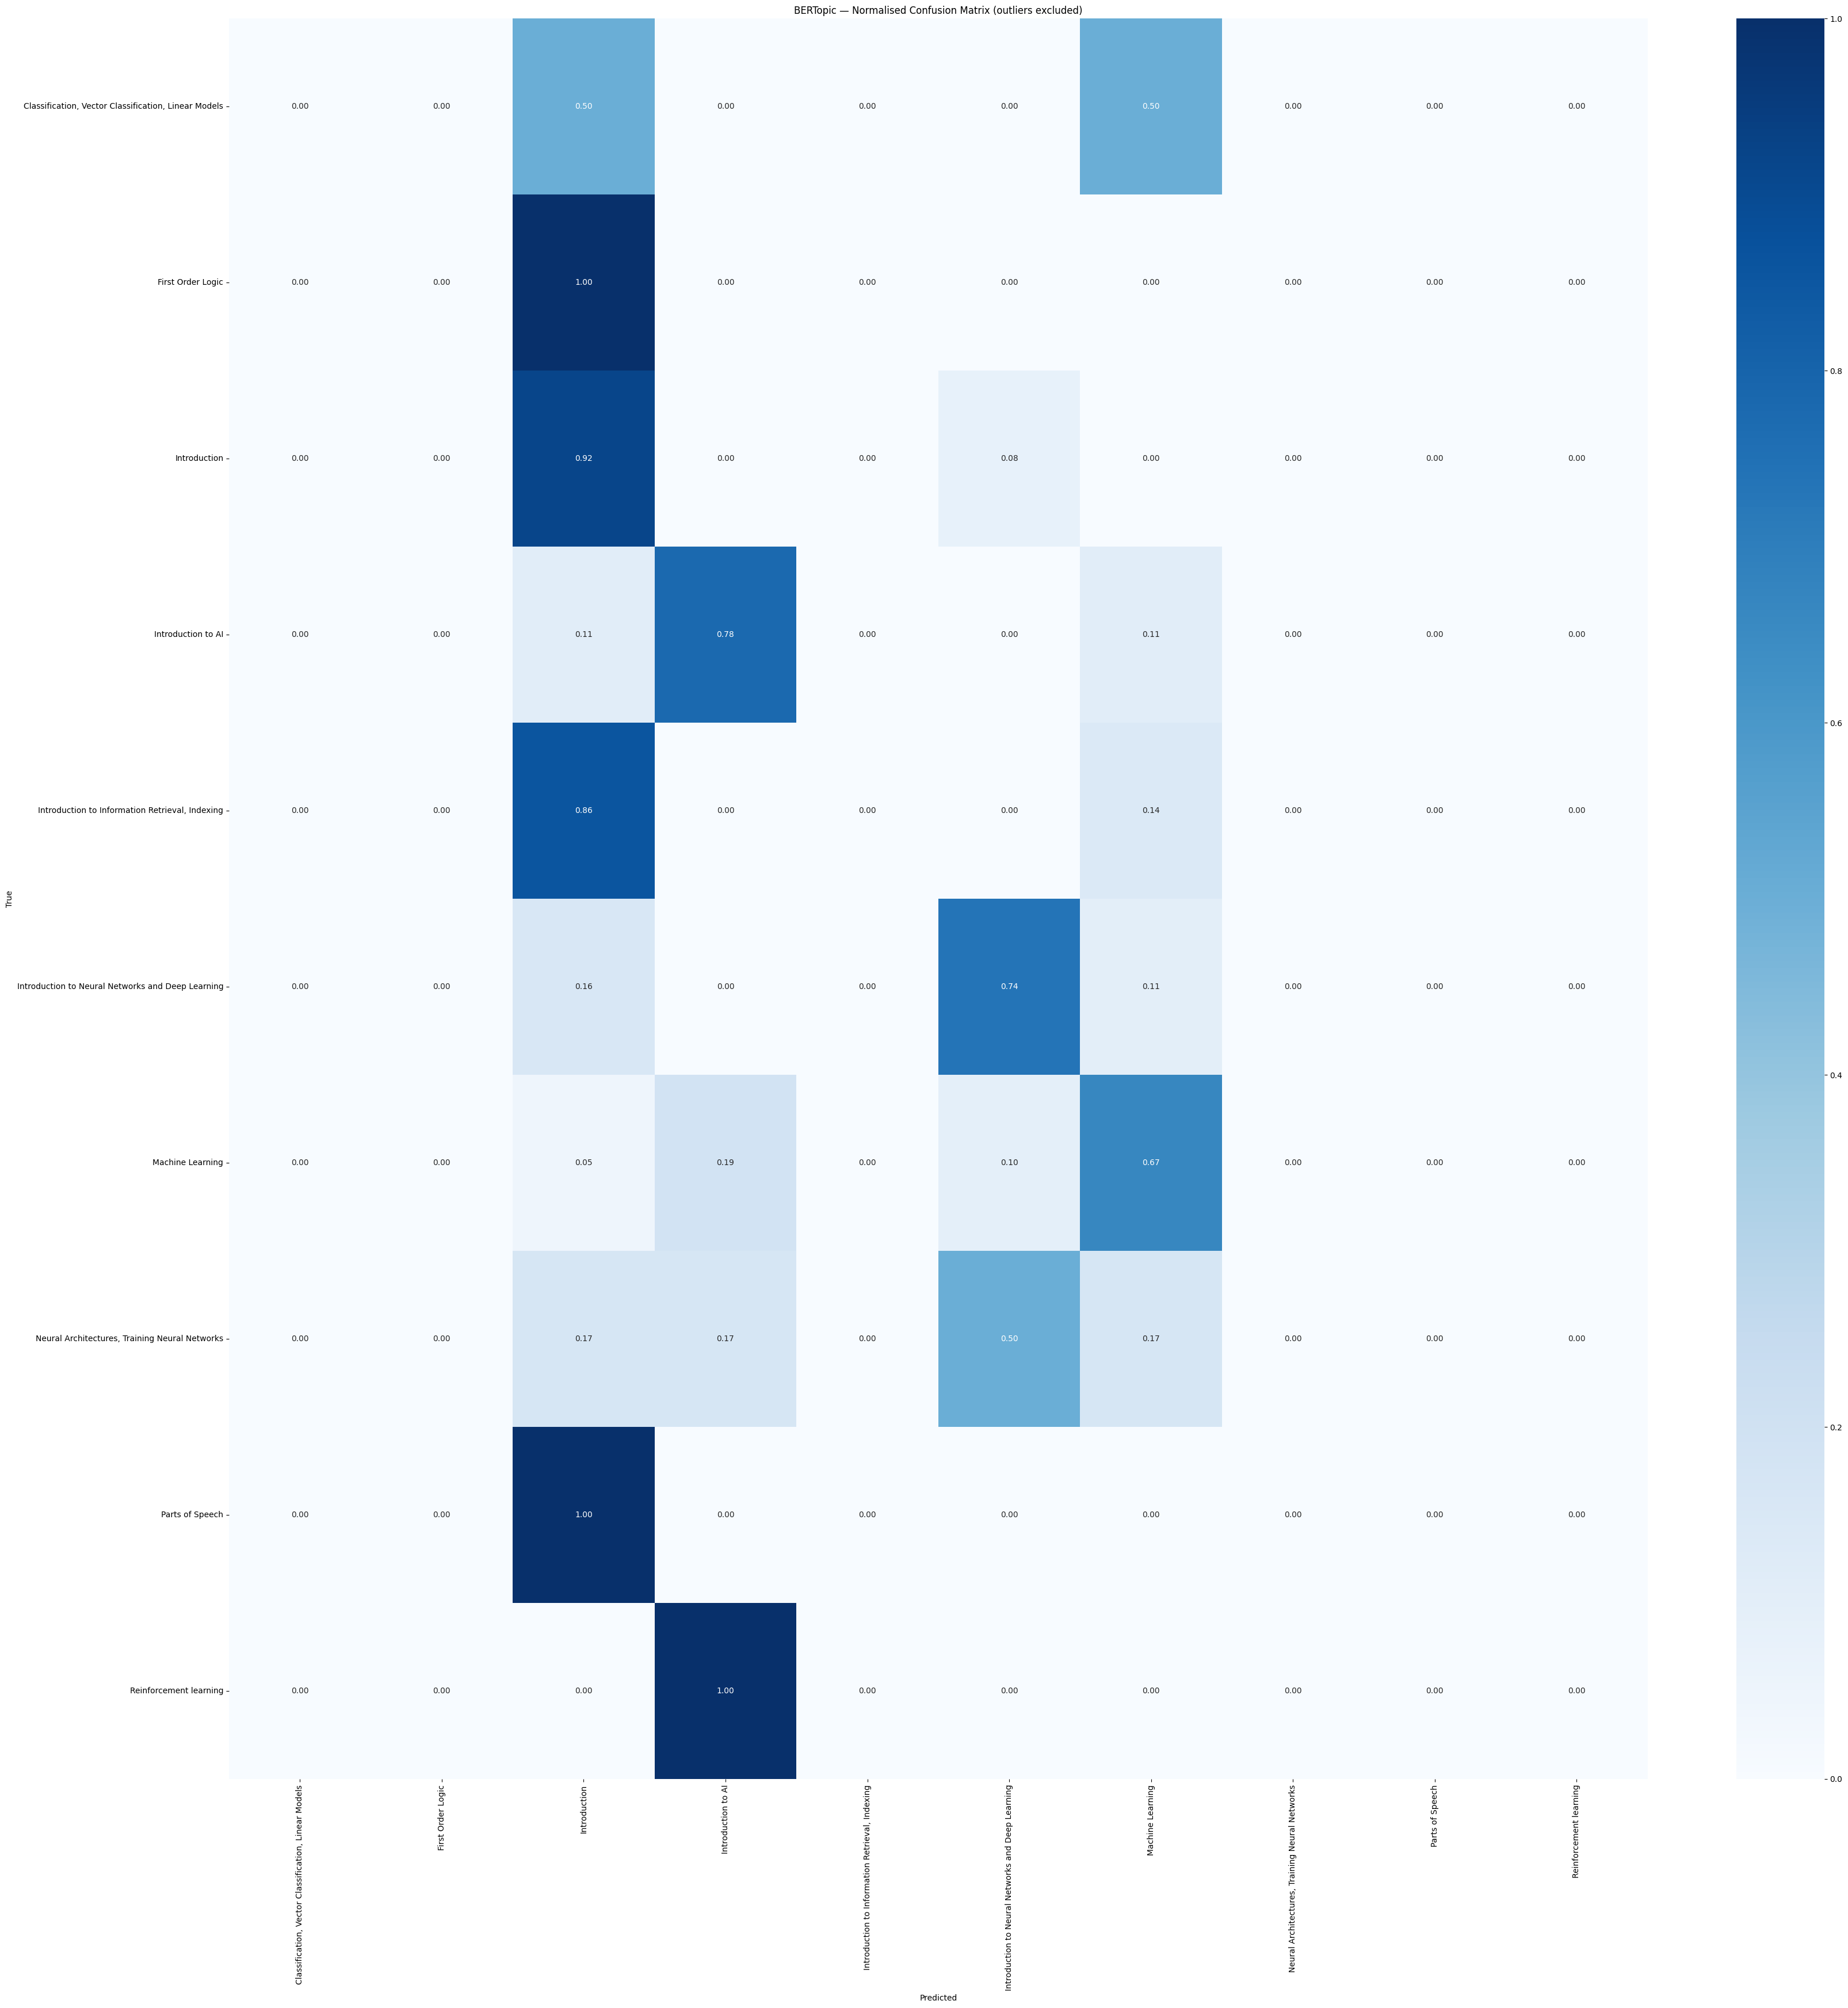

In [69]:
cm_norm = confusion_matrix(df_eval["label"], df_eval["predicted_label"],
                           labels=labels, normalize="true")

plt.figure(figsize=(35,35))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Normalised Confusion Matrix (outliers excluded)")
plt.tight_layout()
plt.show()

In [70]:
coverage = len(df_eval) / len(df)
outlier_breakdown = df[df["topic"] == -1]["label"].value_counts()

print(f"Coverage: {coverage:.1%}")
print("\nOutlier distribution by true label:")
print(outlier_breakdown)

Coverage: 81.9%

Outlier distribution by true label:
label
Machine Learning                                        10
Introduction to Neural Networks and Deep Learning        9
Introduction                                             4
Classification, Vector Classification, Linear Models     2
Introduction to AI                                       2
First Order Logic                                        1
Name: count, dtype: int64


In [71]:
# Total documents per true label
total_per_label = df["label"].value_counts()

# Percentage of each class that became an outlier
outlier_rate = (outlier_breakdown / total_per_label * 100).round(1)

print("Outlier rate by class:")
print(outlier_rate.sort_values(ascending=False))

Outlier rate by class:
label
Classification, Vector Classification, Linear Models    33.3
Machine Learning                                        32.3
Introduction to Neural Networks and Deep Learning       32.1
First Order Logic                                       25.0
Introduction to AI                                      18.2
Introduction                                             7.4
Introduction to Information Retrieval, Indexing          NaN
Neural Architectures, Training Neural Networks           NaN
Parts of Speech                                          NaN
Reinforcement learning                                   NaN
Name: count, dtype: float64


**Including outliers**

In [72]:
# Reassign outliers to their closest topic using embedding similarity
topics_updated = topic_model.reduce_outliers(documents=texts, topics=topics, strategy="embeddings")

remaining_outliers = sum(t == -1 for t in topics_updated)
print(f"Outliers before: {sum(t == -1 for t in topics)}")
print(f"Outliers after:  {remaining_outliers}")

Outliers before: 28
Outliers after:  0


In [73]:
# Replace the topic column with the updated assignments
df["topic_updated"] = topics_updated
df["predicted_label_updated"] = df["topic_updated"].map(topic_to_label)

In [74]:
df

,text,split,label,topic,predicted_label,topic_updated,predicted_label_updated
0,Learning From Data Lecture 13 Validation and M...,all,"Neural Architectures, Training Neural Networks",2,Machine Learning,2,Machine Learning
1,Lecture 11: Annotation Nathan Schneider (with ...,all,Introduction,0,Introduction,0,Introduction
2,Linear Classifiers and Perceptron CS6780 – Adv...,all,Machine Learning,2,Machine Learning,2,Machine Learning
3,NLP Introduction to NLP Parts of speech Syntac...,all,Parts of Speech,0,Introduction,0,Introduction
4,2/23/2019 pooling slides Maximum Pooling and A...,all,Introduction to Neural Networks and Deep Learning,1,Introduction to Neural Networks and Deep Learning,1,Introduction to Neural Networks and Deep Learning
...,...,...,...,...,...,...,...
150,Relation Extraction What is relation extractio...,all,Introduction,0,Introduction,0,Introduction
151,CS 6316 Machine Learning Model Selection and V...,all,Machine Learning,2,Machine Learning,2,Machine Learning
152,Automatic Dialect/Accent Recognition Fadi Biad...,all,Parts of Speech,0,Introduction,0,Introduction
153,10-707: Advanced Deep Learning Spring 2020 Lec...,all,Introduction to Neural Networks and Deep Learning,-1,NaN,1,Introduction to Neural Networks and Deep Learning


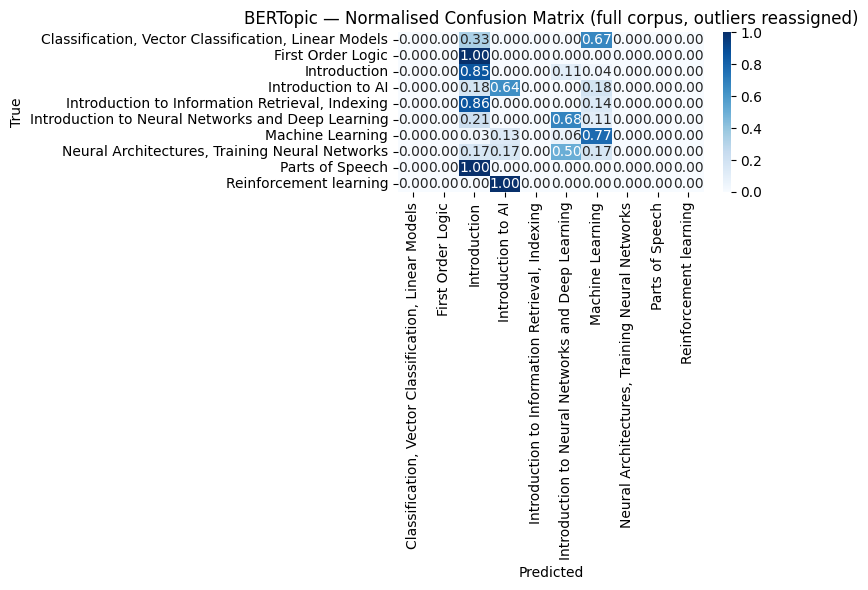

In [75]:
# Now evaluate on the entire corpus
cm_full = confusion_matrix(df["label"], df["predicted_label_updated"],
                           labels=labels, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_full, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Normalised Confusion Matrix (full corpus, outliers reassigned)")
plt.tight_layout()
plt.show()

In [76]:
print(classification_report(df["label"], df["predicted_label_updated"], labels=labels))

                                                      precision    recall  f1-score   support

Classification, Vector Classification, Linear Models       0.00      0.00      0.00         6
                                   First Order Logic       0.00      0.00      0.00         4
                                        Introduction       0.64      0.85      0.73        54
                                  Introduction to AI       0.44      0.64      0.52        11
     Introduction to Information Retrieval, Indexing       0.00      0.00      0.00         7
   Introduction to Neural Networks and Deep Learning       0.63      0.68      0.66        28
                                    Machine Learning       0.65      0.77      0.71        31
      Neural Architectures, Training Neural Networks       0.00      0.00      0.00         6
                                     Parts of Speech       0.00      0.00      0.00         4
                              Reinforcement learning       

In [77]:
from sklearn.metrics import accuracy_score, f1_score

summary_df = pd.DataFrame({
    "Evaluated docs": [len(df_eval), len(df)],
    "Coverage": [f"{len(df_eval)/len(df):.1%}", "100%"],
    "Accuracy": [
        round(accuracy_score(df_eval["label"], df_eval["predicted_label"]), 3),
        round(accuracy_score(df["label"], df["predicted_label_updated"]), 3),
    ],
    "Macro F1": [
        round(f1_score(df_eval["label"], df_eval["predicted_label"], average="macro"), 3),
        round(f1_score(df["label"], df["predicted_label_updated"], average="macro"), 3),
    ],
}, index=["Outliers excluded", "Outliers reassigned"])

summary_df

,Evaluated docs,Coverage,Accuracy,Macro F1
Outliers excluded,127,81.9%,0.638,0.268
Outliers reassigned,155,100%,0.619,0.261


Clustering methods

In [78]:
file_path = "/content/corpus_lecturebank.tsv"

df = pd.read_csv(file_path, sep="\t", header=None)
df.columns = ["text", "split", "label"]

# Preview
df.head()

,text,split,label
0,Learning From Data Lecture 13 Validation and M...,all,"Neural Architectures, Training Neural Networks"
1,Lecture 11: Annotation Nathan Schneider (with ...,all,Introduction
2,Linear Classifiers and Perceptron CS6780 – Adv...,all,Machine Learning
3,NLP Introduction to NLP Parts of speech Syntac...,all,Parts of Speech
4,2/23/2019 pooling slides Maximum Pooling and A...,all,Introduction to Neural Networks and Deep Learning


In [79]:
texts = df["text"].astype(str).tolist()

print(texts[:3])

['Learning From Data Lecture 13 Validation and Model Selection The Validation Set Model Selection Cross Validation M. Magdon-Ismail CSCI 4100/6100 recap: Regularization Regularization combats the eﬀects of noise by putting a leash on the algorithm. Eaug(h) = Ein(h) + λ N Ω(h) Ω(h) → smooth, simple h noise is rough, complex. Diﬀerent regularizers give diﬀerent results can choose λ, the amount of regularization. λ = 0 λ = 0.0001 λ = 0.01 λ = 1 Data Target Fit y y y y x Overﬁtting x → x → x Underﬁtting Optimal λ balances approximation and generalization, bias and variance. AML Creator: Malik Magdon-Ismail c (cid:13) Validation and Model Selection: 2 /31 Peeking at Eout −→ Validation: A Sneak Peek at Eout Eout(g) = Ein(g) + overﬁt penalty VC bounds this using a complexity error bar Ω( ) H regularization estimates this through a heuristic complexity penalty Ω(g) {z | } Validation goes directly for the jugular: Eout(g) = Ein(g) + overﬁt penalty. validation estimates this directly | {z } In-s

In [80]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [81]:
embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(embeddings.shape)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

(155, 384)


In [82]:
embeddings_norm = normalize(embeddings, norm="l2") #Normalization for similarity calculations

Labels to evaluate

In [83]:
true_labels = df["label"]

In [84]:
true_labels.unique()

array(['Neural Architectures, Training Neural Networks', 'Introduction',
       'Machine Learning', 'Parts of Speech',
       'Introduction to Neural Networks and Deep Learning',
       'Reinforcement learning',
       'Classification, Vector Classification, Linear Models',
       'Introduction to Information Retrieval, Indexing',
       'Introduction to AI', 'First Order Logic'], dtype=object)

In [85]:
le = LabelEncoder()
true_labels_encoded = le.fit_transform(true_labels)

print(list(le.classes_))  #see label mapping

['Classification, Vector Classification, Linear Models', 'First Order Logic', 'Introduction', 'Introduction to AI', 'Introduction to Information Retrieval, Indexing', 'Introduction to Neural Networks and Deep Learning', 'Machine Learning', 'Neural Architectures, Training Neural Networks', 'Parts of Speech', 'Reinforcement learning']


**KMeans**

In [86]:
k = 10

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings_norm)

print(kmeans_labels[:10])

[4 1 4 9 6 7 1 4 3 2]


In [87]:
ari = adjusted_rand_score(true_labels_encoded, kmeans_labels)
nmi = normalized_mutual_info_score(true_labels_encoded, kmeans_labels)
sil = silhouette_score(embeddings_norm, kmeans_labels)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Silhouette Score: {sil:.4f}")

ARI: 0.2054
NMI: 0.3801
Silhouette Score: 0.0396


**HDBScan**

In [88]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    metric='euclidean',
    cluster_selection_epsilon=0.1
)

hdb_labels = hdb.fit_predict(embeddings_norm)

print(hdb_labels[:20])
print(f"Unique clusters: {len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)}")
print(f"Noise points: {(hdb_labels == -1).sum()} / {len(hdb_labels)}")

[ 1 -1  1  1 -1  2  1  1  1 -1  1  1  0  1  1  0  1  1  1  1]
Unique clusters: 3
Noise points: 77 / 155


In [89]:
noise_ratio = sum(hdb_labels == -1) / len(hdb_labels)
print(noise_ratio)

0.4967741935483871


In [90]:
mask = hdb_labels != -1

filtered_labels = hdb_labels[mask]
filtered_true = true_labels_encoded[mask]
filtered_embeddings = embeddings_norm[mask]

print("Remaining points:", len(filtered_labels))

Remaining points: 78


In [91]:
print("Unique labels:", np.unique(hdb_labels))
print("Noise points:", sum(hdb_labels == -1))
print("Num clusters:", len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0))

Unique labels: [-1  0  1  2]
Noise points: 77
Num clusters: 3


In [92]:
ari_hdb = adjusted_rand_score(filtered_true, filtered_labels)
nmi_hdb = normalized_mutual_info_score(filtered_true, filtered_labels)

# Silhouette only if >1 cluster
if len(set(filtered_labels)) > 1:
    sil_hdb = silhouette_score(filtered_embeddings, filtered_labels)
else:
    sil_hdb = -1

In [93]:
ari_hdb_full = adjusted_rand_score(true_labels_encoded, hdb_labels)
nmi_hdb_full = normalized_mutual_info_score(true_labels_encoded, hdb_labels)

print(f"HDBSCAN ARI (no noise): {ari_hdb:.4f}")
print(f"HDBSCAN ARI (full):     {ari_hdb_full:.4f}")
print(f"HDBSCAN NMI (no noise): {nmi_hdb:.4f}")
print(f"HDBSCAN NMI (full):     {nmi_hdb_full:.4f}")
print(f"HDBSCAN Silhouette:     {sil_hdb:.4f}")

HDBSCAN ARI (no noise): 0.1431
HDBSCAN ARI (full):     0.0518
HDBSCAN NMI (no noise): 0.2286
HDBSCAN NMI (full):     0.1526
HDBSCAN Silhouette:     0.0703


In [94]:
comparison = pd.DataFrame({
    'ARI': [ari, ari_hdb_full],
    'NMI': [nmi, nmi_hdb_full],
    'Silhouette': [sil, sil_hdb],
    'N_clusters': [
        k,
        len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0),
    ],
    'Coverage': [
        1.0,
        (hdb_labels != -1).mean(),
    ],
}, index=['KMeans', 'HDBSCAN']).round(3)

comparison

,ARI,NMI,Silhouette,N_clusters,Coverage
KMeans,0.205,0.380,0.04,10,1.000
HDBSCAN,0.052,0.153,0.07,3,0.503
